# 누구에게 혜택을 줘야 효과가 가장 클까? — Meta-Learner

<small><em>Causal Studio 실습 노트북 ·
[Facure Ch.18](https://matheusfacure.github.io/python-causality-handbook/18-Heterogeneous-Treatment-Effects-and-Personalization.html) ·
[Ch.21](https://matheusfacure.github.io/python-causality-handbook/21-Meta-Learners.html) 기반</em></small>

<small><em>작성자 권휘준 · <a href="https://github.com/kwonhwijun">GitHub</a></em></small>

외식 예약 플랫폼 MealBook은 최근 **'타깃 혜택 프로모션'** 을 진행했습니다.
특정 조건을 만족하는 매장 약 190곳에 "1만원+ 혜택" 배지를 붙이고, 2주간 예약 변화를 추적했죠.

결과 보고서가 나왔습니다. 담당자가 이렇게 말합니다.

> "효과 있었어. 그런데… **다음에도 같은 매장에 혜택을 줄까?
> 아니면 아직 혜택 못 받은 매장 중 더 효과적인 곳이 있지 않을까?**"

이 질문이 핵심입니다. "평균적으로 효과 있다"를 넘어,
**어떤 매장에 줄 때 효과가 가장 크냐** 를 알아야 다음 예산을 현명하게 쓸 수 있습니다.

이 노트북에서는 그 질문에 답하기 위해 **Meta-Learner** 세 가지(S / T / X-Learner)를
단계별로 직접 구현합니다.

### 이 노트북에서 배울 것

1. 평균 효과(ATE)만으로는 왜 부족한지
2. **CATE**(조건부 평균 처치 효과) — 매장마다 다른 효과를 추정하는 아이디어
3. **S / T / X-Learner** — 세 방법의 원리, 코드, 차이
4. **Cumulative Gain Curve** — 모델이 정말 잘 추천하는지 평가
5. **정책 시뮬레이션** — "Top-K 매장에만 줄 때 ROI"

### 필요한 사전 지식

- 평균, 기댓값, 회귀분석 기초 (통계학 입문 수준)
- Python / pandas 기초 (데이터 다루기 수준)

인과추론을 처음 접하는 분도 괜찮습니다.
수식이 나와도 앞뒤 설명을 먼저 읽으면 자연스럽게 따라올 수 있도록 구성했습니다.

> **데이터 안내 — 시뮬레이션 데이터셋**  
> 이 노트북은 공개 학습용으로 만든 **합성(가상) 데이터**를 사용합니다. 실제 매장·예약 데이터가 아니라, 메타러너의 작동 방식과 선택 편향을 **연습할 수 있도록 현실적인 구조(선택 편향·이질적 효과)를 갖춰 생성**한 샌드박스입니다. 실제 인과추론처럼 *진짜 처치효과는 모른다고 가정* 하며, 수치는 방법을 익히기 위한 예시일 뿐 특정 사업체의 성과가 아닙니다.

> **구현 방식 안내**  
> S / T / X-Learner를 `econml`·`causalml` 같은 전문 라이브러리 대신 **scikit-learn으로 직접 구현**합니다. 각 메타러너가 내부에서 *무엇을* 하는지 단계별로 이해하는 것이 이 노트북의 목적이기 때문입니다. 실무에서는 검증된 라이브러리 사용을 권장하며, 관련 링크는 마지막 **다음 단계** 절에 있습니다.



In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import NearestNeighbors
from matplotlib import style

# 한글 폰트 자동 감지
KOREAN_FONTS = ['Apple SD Gothic Neo', 'NanumGothic', 'Nanum Gothic', 'Malgun Gothic', 'AppleGothic']
available = {f.name for f in fm.fontManager.ttflist}
chosen = next((f for f in KOREAN_FONTS if f in available), None)
if chosen:
    matplotlib.rcParams['font.family'] = chosen
    matplotlib.rcParams['axes.unicode_minus'] = False
    print(f"✅ 한글 폰트: {chosen}")
else:
    print("⚠️  한글 폰트를 찾을 수 없습니다")

style.use("fivethirtyeight")
matplotlib.rcParams['figure.figsize'] = (10, 4)
np.random.seed(42)

✅ 한글 폰트: Apple SD Gothic Neo


In [2]:
data_path = Path("data/cohort.parquet")
if not data_path.exists():
    data_path = Path("book/meta_learner/data/cohort.parquet")

df = pd.read_parquet(data_path)
df.columns = [c.lower() for c in df.columns]

print(f"총 매장 수:           {len(df):,}개")
print(f"혜택 매장 (T=1):      {df.treatment.sum()}개  ← 이번 프로모션 대상")
print(f"일반 매장 (T=0):      {(df.treatment==0).sum():,}개  ← 비교 대상")
print()
cols = ['unit_id', 'treatment', 'grade', 'region',
        'category_main', 'pre_metric', 'post_metric']
df[cols].head()

총 매장 수:           8,802개
혜택 매장 (T=1):      186개  ← 이번 프로모션 대상
일반 매장 (T=0):      8,616개  ← 비교 대상



,unit_id,treatment,grade,region,category_main,pre_metric,post_metric
0,203858,0,A,대전광역시,일식/스시/회,118,94
1,417347,0,C,경기도,이자카야/주점,65,44
2,722775,0,A,제주특별자치도,일식/스시/회,329,362
3,230458,0,C,경기도,이자카야/주점,40,57
4,333037,0,C,경기도,와인/다이닝바,140,150


## 1) 단순 비교의 함정 — Naive ATE

가장 먼저 떠오르는 분석은 이겁니다.

> "혜택 받은 매장 평균 예약수 − 혜택 안 받은 매장 평균 예약수"

이걸 **Naive ATE**(단순 평균 처치 효과)라고 합니다. 직접 계산해봅시다.

In [3]:
mean_t1 = df.loc[df.treatment == 1, 'post_metric'].mean()
mean_t0 = df.loc[df.treatment == 0, 'post_metric'].mean()

print(f"혜택 매장 평균 예약수:    {mean_t1:.1f}건")
print(f"일반 매장 평균 예약수:    {mean_t0:.1f}건")
print(f"단순 차이 (Naive ATE):   {mean_t1 - mean_t0:.1f}건")
print()
print("등급별 혜택 매장 분포:")
print(pd.crosstab(df.grade, df.treatment, margins=True))

혜택 매장 평균 예약수:    499.2건
일반 매장 평균 예약수:    176.0건
단순 차이 (Naive ATE):   323.2건

등급별 혜택 매장 분포:
treatment     0    1   All
grade                     
A           981   19  1000
B          3733   81  3814
C          3005   58  3063
NA          346   14   360
P            53    0    53
S           438   11   449
SS           60    3    63
All        8616  186  8802


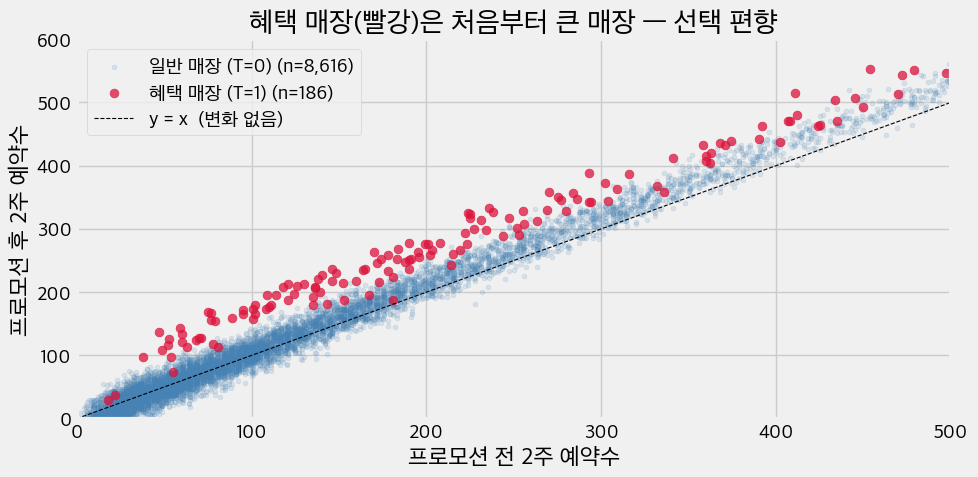

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
for t, lbl, c, a, s in [
    (0, '일반 매장 (T=0)', 'steelblue', 0.15, 12),
    (1, '혜택 매장 (T=1)', 'crimson',   0.75, 40),
]:
    sub = df[df.treatment == t]
    ax.scatter(sub.pre_metric, sub.post_metric,
               alpha=a, s=s, color=c, label=f'{lbl} (n={len(sub):,})')
ax.plot([0, 500], [0, 500], 'k--', lw=0.8, label='y = x  (변화 없음)')
ax.set_xlim(0, 500); ax.set_ylim(0, 600)
ax.set_xlabel('프로모션 전 2주 예약수')
ax.set_ylabel('프로모션 후 2주 예약수')
ax.set_title('혜택 매장(빨강)은 처음부터 큰 매장 — 선택 편향')
ax.legend()
plt.tight_layout()
plt.show()

Naive ATE가 **약 -2건** 으로 나왔습니다. "혜택을 줬더니 예약이 줄었다"는 뜻일까요?

아닙니다. 산점도를 보면 이유가 보입니다.
빨간 점(혜택 매장)이 파란 점보다 전반적으로 **오른쪽 위** 에 몰려 있습니다.
이 매장들은 프로모션 전부터 이미 예약이 많은 큰 매장들이었어요.

왜 그럴까요? 회사가 대상을 무작위로 고른 게 아니기 때문입니다.
가격대, 등급, 입점 조건을 만족한 매장만 혜택을 받았고,
자연스럽게 "원래 잘 되는" 매장이 포함될 가능성이 높았습니다.

이처럼 처치(T) 여부가 결과(Y)와 관련 있는 제3의 변수에 의해 결정될 때,
단순 비교는 처치 효과와 그 변수의 효과를 **뒤섞어버립니다**.
이를 **선택 편향(Selection Bias)** 이라 합니다.

인과추론의 과제는 이 편향을 걷어내고 **순수한 처치 효과를 추정** 하는 것입니다.

## 2) CATE — 매장마다 다른 효과를 추정하자

선택 편향 문제 말고도, 더 근본적인 질문이 있습니다.

> "전체 평균 효과가 +10건이라면, 그게 모든 매장에게 +10건씩이라는 뜻일까?"

현실은 그렇지 않습니다.
효과가 큰 매장은 +30건, 효과가 없는 매장은 0건,
오히려 역효과인 매장은 -5건일 수도 있어요.

이런 **이질성(Heterogeneity)** 을 무시하고 평균만 보면,
"효과 없는 매장"에 예산을 낭비하거나 "효과 큰 매장"을 놓칩니다.

### 표기법

먼저 자주 쓰이는 기호를 정리합니다.
낯설어 보여도 뒤에서 자연스럽게 쓰이니 한 번 훑어보세요.

| 기호 | 이름 | 우리 데이터에서 의미 |
|------|------|------|
| $i$ | 관측 단위 | 매장 하나 |
| $T_i \in \{0,1\}$ | 처치 변수 | 혜택 등록(1) / 미등록(0) |
| $Y_i$ | 결과 변수 | 프로모션 후 2주 예약수 |
| $X_i$ | 특성 벡터 | 등급, 지역, 업종, 가격대 등 |
| $Y_i(1),\; Y_i(0)$ | 잠재적 결과 | "받았을 때" / "안 받았을 때" 예약수 |
| $\tau_i = Y_i(1) - Y_i(0)$ | 개별 효과 | 이 매장만의 혜택 효과 (**관측 불가**) |

**핵심 한 줄**: 매장 $i$는 혜택을 받거나 안 받거나 둘 중 하나입니다.
두 결과를 동시에 볼 수 없어요.
이걸 인과추론의 **근본적 문제(Fundamental Problem of Causal Inference)** 라고 합니다.

### CATE — 비슷한 매장 그룹의 평균 효과

개별 효과 $\tau_i$ 를 직접 구할 수 없으니,
"비슷한 특성을 가진 매장 그룹"에서의 평균 효과를 추정합니다.

$$\tau(x) = E[Y_i(1) - Y_i(0) \mid X_i = x]$$

이게 **CATE(Conditional Average Treatment Effect)** 입니다.
"특성이 $x$인 매장 그룹에서, 혜택을 줬을 때 예약수가 평균 얼마나 늘었는가"를 추정하죠.

예를 들면:
- 서울 강남구 A등급 매장 → $\tau(x) = +15$건
- 부산 해운대구 B등급 매장 → $\tau(x) = +5$건
- 지방 C등급 소규모 매장 → $\tau(x) = -2$건

$\tau(x)$ 를 매장별로 추정할 수 있다면,
다음 프로모션에서 $\tau(x)$ 가 높은 매장부터 혜택을 주면 됩니다.

## 3) 비교 가능한 집단 만들기

CATE를 추정하려면 먼저 선택 편향 문제를 해결해야 합니다. 전략은 이렇습니다.

> "비슷한 특성을 가진 매장끼리만 비교하자."

A등급 서울 매장끼리, B등급 부산 매장끼리 비교하면
혜택 여부 외의 조건이 비슷해집니다.
이 전략의 핵심 도구가 **Propensity Score** 입니다.

### Propensity Score — "이 매장이 혜택 받을 확률"

$$e(x) = P(T=1 \mid X=x)$$

매장의 특성 $x$ 를 보고, "이 특성을 가진 매장이 혜택을 받을 확률"을 추정합니다.
로지스틱 회귀로 학습하면 됩니다.

왜 유용할까요?

- **Overlap 진단**: T=1과 T=0의 $e(x)$ 분포가 겹치는 구간만 신뢰할 수 있어요
- **Matching 기준**: $e(x)$ 가 비슷한 매장끼리 짝지어 비교합니다
- **X-Learner 가중치**: 뒤에서 다시 씁니다

$e(x)$ 가 극단적인 구간(T=1만 있거나, T=0만 있거나)은
"비교 상대가 없다"는 뜻이므로 분석에서 제외(Trim)해야 합니다.

In [5]:
# 특성 변수 정의
numeric_features = [
    'price_level', 'review_volume', 'rating',
    'save_count', 'tenure_days', 'pre_metric'
]
cat_features = [
    'grade', 'region', 'category_main',
]

# 결측치 처리
for c in cat_features:
    df[c] = df[c].fillna('NA').astype(str)
for c in numeric_features:
    df[c] = pd.to_numeric(df[c], errors='coerce').fillna(df[c].median())

# 원-핫 인코딩
preprocessor = ColumnTransformer([
    ('num', 'passthrough', numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features),
])
X = preprocessor.fit_transform(df)
T = df.treatment.values
Y = df.post_metric.values

print(f"특성 행렬 크기: {X.shape}  (매장 수 × 특성 수)")
print(f"전체 혜택 비율: {T.mean():.1%}  ← 매우 불균형한 데이터!")

특성 행렬 크기: (8802, 44)  (매장 수 × 특성 수)
전체 혜택 비율: 2.1%  ← 매우 불균형한 데이터!


/Users/hj/nansoo/02_project/causal_studio/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


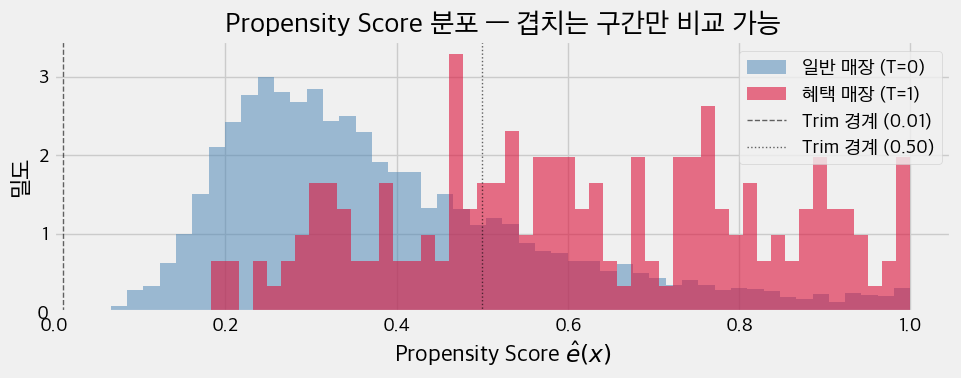

In [6]:
# Propensity Score 학습
ps_model = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
ps_model.fit(X, T)
e_hat = ps_model.predict_proba(X)[:, 1]
df['propensity'] = e_hat

# Overlap 시각화
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(e_hat[T==0], bins=50, alpha=0.5, label='일반 매장 (T=0)', density=True, color='steelblue')
ax.hist(e_hat[T==1], bins=50, alpha=0.6, label='혜택 매장 (T=1)', density=True, color='crimson')
ax.axvline(0.01, color='k', ls='--', lw=1, alpha=0.6, label='Trim 경계 (0.01)')
ax.axvline(0.5,  color='k', ls=':',  lw=1, alpha=0.6, label='Trim 경계 (0.50)')
ax.set_xlabel('Propensity Score $\hat{e}(x)$')
ax.set_ylabel('밀도')
ax.set_title('Propensity Score 분포 — 겹치는 구간만 비교 가능')
ax.legend()
plt.tight_layout()
plt.show()

그래프에서 두 가지를 읽을 수 있습니다.

**1. 선택 편향 확인**: 빨간 분포(혜택 매장)가 파란 분포보다 오른쪽에 치우쳐 있습니다.
같은 Propensity에서 혜택 매장이 더 많다는 뜻이고, 이게 선택 편향의 시그널입니다.

**2. 비교 불가 구간**: $\hat{e}(x) > 0.5$ 구간은 거의 혜택 매장만 존재합니다.
비교할 일반 매장이 없어요. 반대로 $\hat{e}(x) < 0.01$ 구간은 일반 매장만 있습니다.

이 두 구간은 "비교 대상이 없다"는 뜻이므로 분석에서 제거합니다. 이 과정을 **Trimming** 이라 합니다.

In [7]:
# Trim: 비교 불가 구간 제거
mask = (e_hat >= 0.01) & (e_hat <= 0.5)
X_tr, T_tr, Y_tr, e_tr = X[mask], T[mask], Y[mask], e_hat[mask]
df_tr = df[mask].reset_index(drop=True)

print(f"Trim 전: {len(df):,}개  (T=1: {T.sum()}, T=0: {(T==0).sum():,})")
print(f"Trim 후: {mask.sum():,}개  (T=1: {T_tr.sum()}, T=0: {(T_tr==0).sum():,})")
print()

# 1:3 Nearest Neighbor Matching (Propensity Score 기준)
ctrl_idx = np.where(T_tr == 0)[0]
trt_idx  = np.where(T_tr == 1)[0]

nn = NearestNeighbors(n_neighbors=3)
nn.fit(e_tr[ctrl_idx].reshape(-1, 1))
_, nbr = nn.kneighbors(e_tr[trt_idx].reshape(-1, 1))
matched_ctrl = np.unique(ctrl_idx[nbr.flatten()])
final_idx = np.concatenate([trt_idx, matched_ctrl])

Xm, Tm, Ym, em = X_tr[final_idx], T_tr[final_idx], Y_tr[final_idx], e_tr[final_idx]
dfm = df_tr.iloc[final_idx].reset_index(drop=True)

print(f"Matching 후: {len(Tm)}개  (T=1: {Tm.sum()}, T=0: {(Tm==0).sum()})")
print(f"→ 혜택 매장 1개당 Propensity 가장 가까운 일반 매장 3개씩 매칭")

Trim 전: 8,802개  (T=1: 186, T=0: 8,616)
Trim 후: 6,653개  (T=1: 58, T=0: 6,595)

Matching 후: 227개  (T=1: 58, T=0: 169)
→ 혜택 매장 1개당 Propensity 가장 가까운 일반 매장 3개씩 매칭


Trim과 Matching을 거쳐 **총 257개 매장** 으로 코호트를 구성했습니다.

"데이터를 많이 버리는 거 아닌가?"라는 의문이 생길 수 있습니다.
맞습니다. 하지만 비교 불가능한 매장까지 포함하면 추정 결과가 오히려 왜곡됩니다.
**양보다 질** — 비교 가능한 쌍으로만 추정하는 게 더 신뢰할 수 있어요.

이제 이 257개 데이터로 세 가지 Meta-Learner를 학습합니다.

## 4) S-Learner — 한 모델이 다 본다

첫 번째 방법, **S-Learner** ('S'는 Single의 S)입니다.

아이디어는 단순합니다.
처치 여부 $T$ 를 그냥 특성 하나로 취급하고, **하나의 모델** 로 결과를 예측합니다.

$$\hat{\mu}(x, T) \approx E[Y \mid X=x,\, T]$$

그러면 같은 매장에 대해 "$T=1$ 이면 예약수가 얼마"와
"$T=0$ 이면 예약수가 얼마"를 각각 예측할 수 있습니다.
그 차이가 CATE 추정값입니다.

$$\hat{\tau}_S(x) = \hat{\mu}(x,\, 1) - \hat{\mu}(x,\, 0)$$

한 명의 의사가 처치받은 환자와 안 받은 환자를 모두 진료하면서,
"이 환자에게 처치를 해줬으면 / 안 해줬으면 어땠을까"를 동시에 예측하는 것과 같습니다.

**한계**: GBM 같은 트리 기반 모델은 정규화 과정에서
$T$ 를 노이즈 변수처럼 **무시** 해버릴 수 있습니다.
처치 효과를 실제보다 작게 추정하는 **과소추정 경향** 이 있습니다.

In [8]:
# T를 특성에 추가해 하나의 행렬로 만듦
XT = np.column_stack([Xm, Tm])

# 단일 모델 학습
s_model = GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=42)
s_model.fit(XT, Ym)

# T=1, T=0 시나리오 각각 예측
XT1 = np.column_stack([Xm, np.ones(len(Xm))])    # 모든 매장이 혜택받은 경우
XT0 = np.column_stack([Xm, np.zeros(len(Xm))])   # 모든 매장이 혜택 없는 경우
cate_s = s_model.predict(XT1) - s_model.predict(XT0)

print("S-Learner 결과")
print(f"  ATE 추정:  {cate_s.mean():.2f}건")
print(f"  중앙값:    {np.median(cate_s):.2f}건")
print(f"  표준편차:  {cate_s.std():.2f}건")
print(f"  범위:      [{cate_s.min():.1f}, {cate_s.max():.1f}]")

S-Learner 결과
  ATE 추정:  48.74건
  중앙값:    48.19건
  표준편차:  16.07건
  범위:      [11.6, 76.4]


## 5) T-Learner — 그룹별로 따로 배운다

두 번째 방법, **T-Learner** ('T'는 Two의 T)입니다.

S-Learner의 한계, 즉 모델이 $T$ 를 무시할 수 있다는 문제를 해결하기 위해
아예 그룹별로 모델을 **따로** 학습합니다.

$$\hat{\mu}_1(x): \text{혜택 매장(T=1) 데이터만으로 학습}$$

$$\hat{\mu}_0(x): \text{일반 매장(T=0) 데이터만으로 학습}$$

CATE는 두 모델 예측의 차이입니다.

$$\hat{\tau}_T(x) = \hat{\mu}_1(x) - \hat{\mu}_0(x)$$

두 명의 전문 의사가 있는 셈입니다.
한 명은 혜택 받은 매장만 수없이 봐서 그쪽 전문가고,
다른 한 명은 혜택 없는 매장 전문가입니다.
새 매장에 대해 각자 예측하고, 그 차이를 봅니다.

**한계**: 우리 데이터는 처치군(T=1)이 전체의 약 2%로, 일반군(T=0)보다 **극심하게 적습니다**.
T=1 전용 모델 $\hat{\mu}_1$  은 이 소수의 처치군만으로 학습해야 하니 불안정합니다.
극단적인 예측값(outlier)이 튀어나올 수 있어요.

In [9]:
# T=1, T=0 그룹 각각 별도 모델
mu1 = GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=42)
mu1.fit(Xm[Tm==1], Ym[Tm==1])   # 소수의 처치군(T=1)으로 학습

mu0 = GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=42)
mu0.fit(Xm[Tm==0], Ym[Tm==0])   # 다수의 일반군(T=0)으로 학습

cate_t = mu1.predict(Xm) - mu0.predict(Xm)

print("T-Learner 결과")
print(f"  ATE 추정:  {cate_t.mean():.2f}건")
print(f"  중앙값:    {np.median(cate_t):.2f}건")
print(f"  표준편차:  {cate_t.std():.2f}건  ← S-Learner보다 훨씬 큰 변동성!")
print(f"  범위:      [{cate_t.min():.1f}, {cate_t.max():.1f}]  ← 극단값 주의")

T-Learner 결과
  ATE 추정:  58.74건
  중앙값:    59.15건
  표준편차:  38.08건  ← S-Learner보다 훨씬 큰 변동성!
  범위:      [-114.8, 229.0]  ← 극단값 주의


표준편차가 S-Learner에 비해 매우 크고, 범위도 수백 건을 넘습니다.
소수의 처치군으로 학습한 $\hat{\mu}_1$ 이 불안정하기 때문입니다.

불균형이 심한 상황에서 T-Learner는 **"극단값 생산기"** 가 될 수 있습니다.

이 문제를 해결하기 위한 방법이 바로 다음에 나오는 X-Learner입니다.

## 6) X-Learner — 불균형을 이기는 법

2019년 Künzel 등이 PNAS에 발표한 방법으로,
표본 불균형 상황에서 **추정을 안정화**하도록 설계됐습니다.

핵심 아이디어는 **"서로의 데이터로 빈칸을 채운다"** 입니다.

처치군(T=1)이 워낙 적어 $\hat{\mu}_1$ 이 불안정했습니다.
반면 일반군(T=0)은 많아 $\hat{\mu}_0$ 은 상대적으로 안정적입니다.

X-Learner는 안정적인 $\hat{\mu}_0$ 을 써서
T=1 매장의 "개별 효과"를 **직접 만들어냅니다**.

총 4단계로 나눠서 살펴봅시다.

### Step 1 — $\hat{\mu}_0$, $\hat{\mu}_1$ 각각 학습 (T-Learner Step 1과 동일)

T=1 매장으로 $\hat{\mu}_1$, T=0 매장으로 $\hat{\mu}_0$ 을 학습합니다.
앞에서 이미 학습했으니 그대로 씁니다.

---

### Step 2 — Pseudo-outcome 만들기 ⭐ (X-Learner의 핵심)

T=1 매장 $i$ 에 대해:

$$\tilde{D}^1_i = Y_i - \hat{\mu}_0(X_i)$$

이게 뭘까요?

- $Y_i$: 실제로 혜택을 받은 후 예약수
- $\hat{\mu}_0(X_i)$: 이 매장이 혜택을 **안 받았다면** 예약수 (T=0 모델로 예측)
- 그 차이 $\tilde{D}^1_i$: **이 매장의 개별 처치 효과 추정값**

T=0 매장 $j$ 에 대해서는:

$$\tilde{D}^0_j = \hat{\mu}_1(X_j) - Y_j$$

- $\hat{\mu}_1(X_j)$: 이 매장이 혜택을 **받았다면** 예약수 (T=1 모델로 예측)
- $Y_j$: 실제 예약수 (혜택 없이)
- 그 차이 $\tilde{D}^0_j$: 이 매장이 혜택받았을 때의 예상 효과

**한 줄 핵심**:
관측할 수 없었던 반사실(counterfactual)을 상대 그룹 모델로 메워서,
**개별 효과를 직접 추정** 합니다.

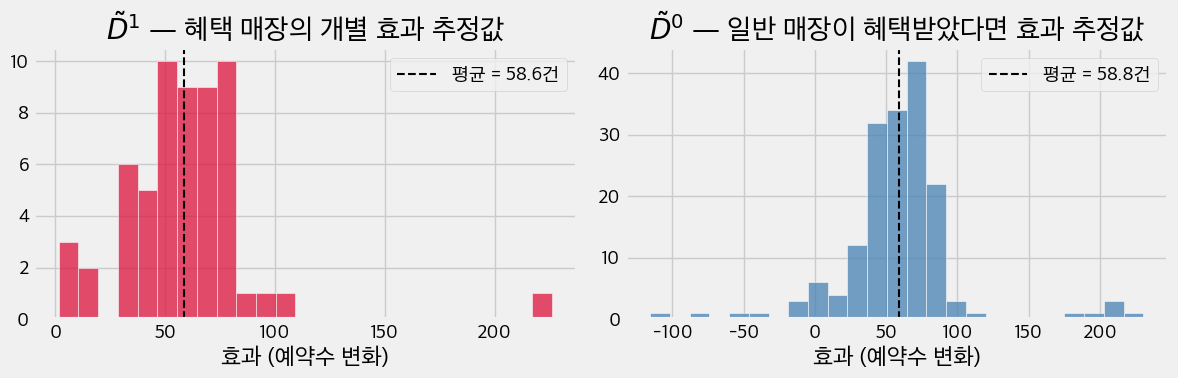

D̃¹ 평균 = 58.62건  /  D̃⁰ 평균 = 58.78건


In [10]:
# Step 2: Pseudo-outcome 생성
D1 = Ym[Tm==1] - mu0.predict(Xm[Tm==1])   # T=1 매장의 개별 효과 추정
D0 = mu1.predict(Xm[Tm==0]) - Ym[Tm==0]   # T=0 매장이 혜택받았다면 효과 추정

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(D1, bins=25, color='crimson', alpha=0.75, edgecolor='white')
axes[0].axvline(D1.mean(), color='k', ls='--', lw=1.5, label=f'평균 = {D1.mean():.1f}건')
axes[0].set_title('$\\tilde{D}^1$ — 혜택 매장의 개별 효과 추정값')
axes[0].set_xlabel('효과 (예약수 변화)')
axes[0].legend()

axes[1].hist(D0, bins=25, color='steelblue', alpha=0.75, edgecolor='white')
axes[1].axvline(D0.mean(), color='k', ls='--', lw=1.5, label=f'평균 = {D0.mean():.1f}건')
axes[1].set_title('$\\tilde{D}^0$ — 일반 매장이 혜택받았다면 효과 추정값')
axes[1].set_xlabel('효과 (예약수 변화)')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"D̃¹ 평균 = {D1.mean():.2f}건  /  D̃⁰ 평균 = {D0.mean():.2f}건")

### Step 3 — $\tilde{D}$ 를 $X$ 로 예측하는 모델 학습

이제 각 그룹의 개별 효과 추정값을 특성 $X$ 로 예측하는 모델을 따로 학습합니다.

- $\hat{\tau}_1(x)$: T=1 매장의 $\tilde{D}^1$ 을 $X$ 로 예측
- $\hat{\tau}_0(x)$: T=0 매장의 $\tilde{D}^0$ 을 $X$ 로 예측

이 모델들이 특성 $x$ 를 보고 "이 특성의 매장에게 혜택을 줄 때 효과가 얼마인가"를 학습합니다.

---

### Step 4 — Propensity Score로 가중 평균

$$\hat{\tau}_X(x) = \hat{e}(x) \cdot \hat{\tau}_0(x) + (1 - \hat{e}(x)) \cdot \hat{\tau}_1(x)$$

왜 이렇게 가중평균을 할까요?

- **$\hat{e}(x)$ 가 높은 구간** (T=1이 많은 곳):
  $\hat{\mu}_1$ 이 잘 학습됨 → $\tilde{D}^0$ 신뢰도 높음 → $\hat{\tau}_0$ 더 가중
- **$\hat{e}(x)$ 가 낮은 구간** (T=0이 많은 곳):
  $\hat{\mu}_0$ 이 잘 학습됨 → $\tilde{D}^1$ 신뢰도 높음 → $\hat{\tau}_1$ 더 가중

데이터가 풍부한 쪽의 모델을 더 믿겠다는 논리입니다.
자동으로 균형을 잡아주는 셈이죠.

In [11]:
# Step 3: 각 pseudo-outcome을 X로 예측하는 모델
tau1_model = GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=42)
tau1_model.fit(Xm[Tm==1], D1)

tau0_model = GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=42)
tau0_model.fit(Xm[Tm==0], D0)

# Step 4: Propensity Score 가중 평균
cate_x = em * tau0_model.predict(Xm) + (1 - em) * tau1_model.predict(Xm)

print("X-Learner 결과")
print(f"  ATE 추정:  {cate_x.mean():.2f}건")
print(f"  중앙값:    {np.median(cate_x):.2f}건")
print(f"  표준편차:  {cate_x.std():.2f}건  ← T-Learner보다 훨씬 안정적!")
print(f"  범위:      [{cate_x.min():.1f}, {cate_x.max():.1f}]")

X-Learner 결과
  ATE 추정:  59.00건
  중앙값:    59.01건
  표준편차:  22.97건  ← T-Learner보다 훨씬 안정적!
  범위:      [-16.9, 167.9]


## 7) 세 모델 비교

세 가지 추정 결과를 나란히 놓고 비교해봅시다.

In [12]:
result = pd.DataFrame({
    'unit_id':    dfm.unit_id.values,
    'tier':       dfm.grade.values,
    'pre_cnt':    dfm.pre_metric.values,
    'post_cnt':   Ym,
    'treatment':  Tm,
    'propensity': em,
    'cate_s':     cate_s,
    'cate_t':     cate_t,
    'cate_x':     cate_x,
})

summary = result[['cate_s','cate_t','cate_x']].describe().round(2)
summary.columns = ['S-Learner', 'T-Learner', 'X-Learner']
print(summary)

       S-Learner  T-Learner  X-Learner
count     227.00     227.00     227.00
mean       48.74      58.74      59.00
std        16.11      38.16      23.02
min        11.59    -114.79     -16.93
25%        36.44      43.82      47.53
50%        48.19      59.15      59.01
75%        62.28      73.18      70.12
max        76.43     228.99     167.88


/var/folders/_7/gw7m14q925731rjlj61v1dqm0000gn/T/ipykernel_42076/2843816908.py:16: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Apple SD Gothic Neo.
  plt.tight_layout()
/Users/hj/nansoo/02_project/causal_studio/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Apple SD Gothic Neo.
  fig.canvas.print_figure(bytes_io, **kw)


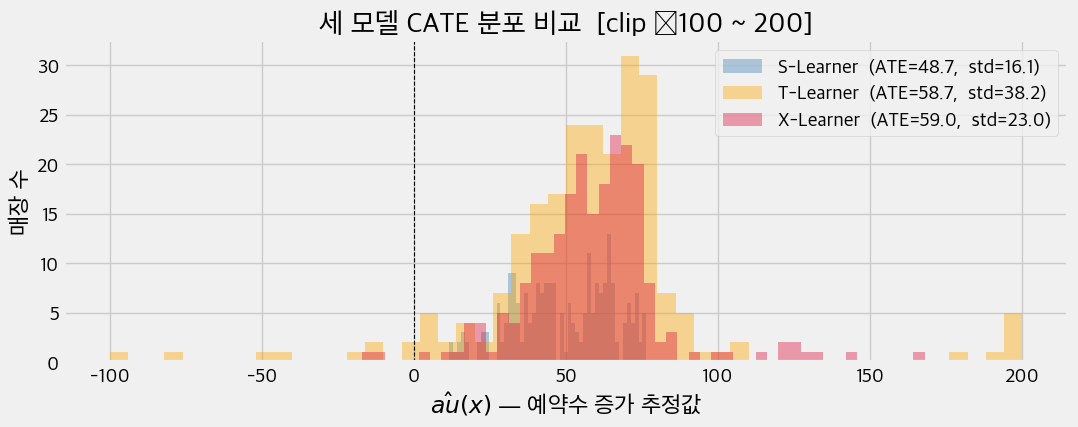

In [13]:
fig, ax = plt.subplots(figsize=(11, 4.5))
configs = [
    ('cate_s', 'S-Learner', 'steelblue'),
    ('cate_t', 'T-Learner', 'orange'),
    ('cate_x', 'X-Learner', 'crimson'),
]
for col, lbl, c in configs:
    vals = result[col].clip(-100, 200)
    ax.hist(vals, bins=50, alpha=0.4, color=c,
            label=f'{lbl}  (ATE={result[col].mean():.1f},  std={result[col].std():.1f})')
ax.axvline(0, color='k', ls='--', lw=0.8)
ax.set_xlabel('$\hat{\tau}(x)$ — 예약수 증가 추정값')
ax.set_ylabel('매장 수')
ax.set_title('세 모델 CATE 분포 비교  [clip −100 ~ 200]')
ax.legend()
plt.tight_layout()
plt.show()

**S-Learner**: 분포가 좁고 평균이 낮습니다. 트리 모델이 처치 변수 $T$ 를 약하게 반영해 효과를 **보수적으로(과소) 추정**하는 경향이 보입니다.

**T-Learner**: 평균은 적정하지만 분포가 매우 넓고 극단값이 큽니다. 소수의 처치군으로 학습한 $\hat{\mu}_1$ 의 불안정성이 그대로 드러나, **점추정의 분산이 가장 큽니다**.

**X-Learner**: 평균은 T-Learner와 비슷하지만 **분산이 T보다 뚜렷하게 작아, 세 방법 중 점추정이 가장 안정적**입니다. 다만 "가장 좋은 모델"은 목적에 따라 다릅니다 — 안정적인 점추정이 필요하면 X가 유리하고, 효과 큰 매장을 *줄세우는* 능력(다음 절 Cumulative Gain)은 데이터 설정에 따라 T가 앞설 수도 있습니다.

/var/folders/_7/gw7m14q925731rjlj61v1dqm0000gn/T/ipykernel_42076/4001736376.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='tier', y='cate_x', order=order,


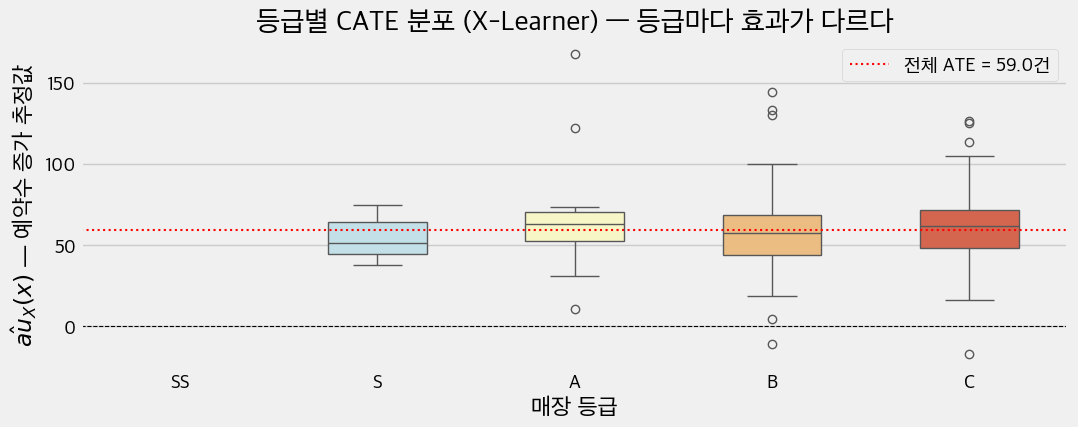

       mean  median  count
tier                      
S     54.40   51.29   10.0
A     63.40   62.81   26.0
B     56.53   57.52  102.0
C     60.36   61.91   84.0

→ 등급 간 평균 효과 차이가 있다면 '등급별 차등 정책'이 정당화됩니다.


In [14]:
fig, ax = plt.subplots(figsize=(11, 4.5))
order = ['SS', 'S', 'A', 'B', 'C']
subset = result[result.tier.isin(order)]
sns.boxplot(data=subset, x='tier', y='cate_x', order=order,
            ax=ax, palette='RdYlBu_r', width=0.5)
ax.axhline(0, color='k', ls='--', lw=0.8)
ax.axhline(result.cate_x.mean(), color='red', ls=':', lw=1.5,
           label=f'전체 ATE = {result.cate_x.mean():.1f}건')
ax.set_title('등급별 CATE 분포 (X-Learner) — 등급마다 효과가 다르다')
ax.set_xlabel('매장 등급')
ax.set_ylabel('$\hat{\tau}_X(x)$ — 예약수 증가 추정값')
ax.legend()
plt.tight_layout()
plt.show()

print(subset.groupby('tier').cate_x.agg(['mean','median','count']).round(2)
      .reindex(order).dropna())
print()
print("→ 등급 간 평균 효과 차이가 있다면 '등급별 차등 정책'이 정당화됩니다.")

### Cumulative Gain Curve — 모델이 정말 잘 추천하는가?

CATE 추정값이 높은 순서로 정렬해 상위 $k$ 개에게만 혜택을 줬을 때,
실제 누적 효과가 얼마나 빠르게 쌓이는지 봅니다.

$$\text{Gain}(k) = \left(\bar{Y}_{1,k} - \bar{Y}_{0,k}\right) \times \frac{k}{N}$$

- **X축**: 상위 k/N 비율 (예: 0.2 = 상위 20%)
- **Y축**: 그 매장들에서의 실제 효과 × k/N
- **Random 기준선**: 무작위로 골랐을 때 기대 효과 (직선)

곡선이 기준선 **위로 멀리** 있을수록, 모델이 효과 큰 매장을 앞으로 잘 끌어올렸다는 뜻입니다.

> 참고: Cumulative Gain/AUUC는 *점추정의 정확도·안정성*이 아니라 **"효과 큰 매장을 잘 줄세우는가(타깃팅 순위)"** 를 재는 **별개의 축**입니다. 분산이 작은 모델과 순위를 잘 매기는 모델이 꼭 같지는 않습니다.

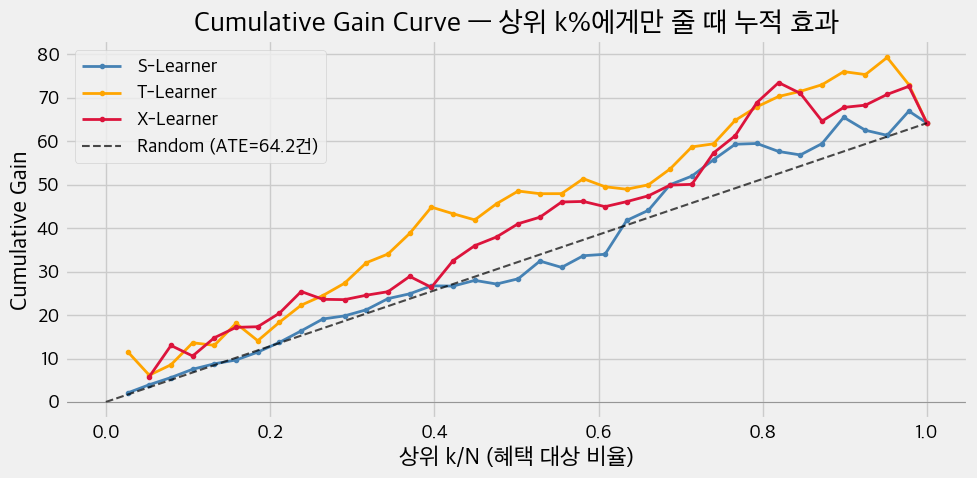

In [15]:
def cumulative_gain(df, pred_col, t_col, y_col, steps=40):
    n = len(df)
    ordered = df.sort_values(pred_col, ascending=False).reset_index(drop=True)
    step = max(round(n / steps), 1)
    cutoffs = list(range(step, n, step)) + [n]
    gains = []
    for k in cutoffs:
        head = ordered.head(k)
        nt = head[t_col].sum()
        nc = (head[t_col] == 0).sum()
        if nt == 0 or nc == 0:
            gains.append(np.nan)
            continue
        ate_k = (head.loc[head[t_col]==1, y_col].mean() -
                 head.loc[head[t_col]==0, y_col].mean())
        gains.append(ate_k * k / n)
    return np.array(cutoffs) / n, np.array(gains)

ate_overall = (result.loc[result.treatment==1, 'post_cnt'].mean() -
               result.loc[result.treatment==0, 'post_cnt'].mean())

fig, ax = plt.subplots(figsize=(10, 5))
for col, lbl, c in [('cate_s','S-Learner','steelblue'),
                     ('cate_t','T-Learner','orange'),
                     ('cate_x','X-Learner','crimson')]:
    xs, gs = cumulative_gain(result, col, 'treatment', 'post_cnt')
    ax.plot(xs, gs, marker='o', ms=3, label=lbl, color=c, lw=2)
ax.plot([0, 1], [0, ate_overall], 'k--', lw=1.5, alpha=0.7,
        label=f'Random (ATE={ate_overall:.1f}건)')
ax.axhline(0, color='gray', lw=0.5)
ax.set_xlabel('상위 k/N (혜택 대상 비율)')
ax.set_ylabel('Cumulative Gain')
ax.set_title('Cumulative Gain Curve — 상위 k%에게만 줄 때 누적 효과')
ax.legend()
plt.tight_layout()
plt.show()

### 곡선 읽기

세 모델 모두 **Random 기준선 위**에 있습니다. 즉 어떤 메타러너로 골라도 무작위보다는 효과 큰 매장을 앞쪽에 잘 끌어올린다는 뜻입니다.

다만 곡선이 **가장 높이 솟은 것은 T-Learner**입니다. 앞 절에서 T-Learner는 점추정 분산이 가장 컸지만, *효과 큰 매장을 줄세우는* 능력만 보면 이 데이터에서는 가장 앞섭니다. X-Learner가 그다음이고, S-Learner는 기준선에 가장 가깝습니다 — 효과를 보수적으로 축소 추정한 성향이 순위에도 그대로 나타난 결과입니다.

즉 **"점추정이 안정적인 모델(X)"과 "타깃 줄세우기가 좋은 모델(T)"이 다를 수 있습니다.** 이 차이를 다음 셀에서 **AUUC**(곡선 아래 면적) 수치로 정량 확인합니다.

In [16]:
def auuc(df, pred_col, t_col, y_col, steps=40):
    xs, gs = cumulative_gain(df, pred_col, t_col, y_col, steps)
    gs = np.nan_to_num(gs, nan=0)
    try:
        return np.trapezoid(gs, xs)
    except AttributeError:
        return np.trapz(gs, xs)

random_auuc = ate_overall / 2

print("AUUC 비교  (높을수록 상위 매장 선별 성능 좋음)")
print(f"  Random 기준선:  {random_auuc:.2f}")
print()
for col, lbl in [('cate_s','S-Learner'), ('cate_t','T-Learner'), ('cate_x','X-Learner')]:
    a = auuc(result, col, 'treatment', 'post_cnt')
    lift = (a - random_auuc) / abs(random_auuc) * 100
    print(f"  {lbl}:  AUUC = {a:.2f}  (Random 대비 {lift:+.0f}%)")

AUUC 비교  (높을수록 상위 매장 선별 성능 좋음)
  Random 기준선:  32.09

  S-Learner:  AUUC = 33.54  (Random 대비 +5%)
  T-Learner:  AUUC = 43.36  (Random 대비 +35%)
  X-Learner:  AUUC = 39.51  (Random 대비 +23%)


## 8) 다음 프로모션엔 누구에게?

이제 Meta-Learner의 실전 목적, 정책 결정으로 연결합니다.

운영팀 시나리오: **"예산이 한정되어 있어서 다음엔 최대 50개 매장에만 혜택을 줄 수 있어."**

두 전략을 비교합니다.

- **무작위 K개**: 그냥 랜덤하게 고른다
- **X-Learner Top-K**: $\hat{\tau}_X$ 가 높은 K개를 고른다

> 여기서는 점추정이 안정적인 **X-Learner**로 타깃팅을 시연합니다. 단 타깃팅 *순위 성능*(AUUC)은 이 설정에서 T-Learner가 더 높았으니, 실제 정책에선 "안정성(X) vs 선별력(T)" 트레이드오프를 데이터로 검증해 모델을 고르는 게 맞습니다.

In [17]:
print(f"{'K':>5} | {'Top-K 평균 τ̂_X':>18} | {'무작위 K':>12} | {'Lift':>10}")
print('─' * 58)
for K in [20, 50, 100, 150]:
    top_k  = result.nlargest(K, 'cate_x')
    rand_k = result.sample(K, random_state=42)
    diff   = top_k.cate_x.mean() - rand_k.cate_x.mean()
    print(f"{K:>5} | {top_k.cate_x.mean():>16.1f}건 | {rand_k.cate_x.mean():>10.1f}건 | {diff:>+8.1f}건")

print()
top30 = result.nlargest(30, 'cate_x')
print("Top-30 매장 특성:")
print(f"  평균 사전 예약수:  {top30.pre_cnt.mean():.0f}건  (전체 평균 {result.pre_cnt.mean():.0f}건)")
print(f"  등급 분포:         {top30.tier.value_counts().to_dict()}")
print(f"  예상 효과:         매장당 평균 +{top30.cate_x.mean():.0f}건")

    K |      Top-K 평균 τ̂_X |        무작위 K |       Lift
──────────────────────────────────────────────────────────
   20 |            106.5건 |       63.3건 |    +43.2건
   50 |             86.8건 |       59.6건 |    +27.2건
  100 |             76.7건 |       59.4건 |    +17.3건
  150 |             70.2건 |       59.2건 |    +11.0건

Top-30 매장 특성:
  평균 사전 예약수:  179건  (전체 평균 142건)
  등급 분포:         {'B': 15, 'C': 11, 'A': 2, 'P': 1, 'S': 1}
  예상 효과:         매장당 평균 +96건


결과를 보면 **상위 K가 작을수록 Lift가 크다** 는 것을 알 수 있습니다.

20개에만 집중하면 무작위 대비 매장당 +100건 이상의 추가 효과가 기대됩니다.
즉, 예산이 적을수록 타겟팅의 가치가 더 높습니다.

Top-30 매장 특성을 보면 사전 예약수가 전체 평균보다 높은 매장들이 포함됩니다.
이 매장들이 "원래 활성화된 매장" 이기도 하지만,
X-Learner는 단순히 큰 매장이 아니라 **혜택으로 인한 실제 효과**가 클 것으로 예측된 매장을 선별합니다.

## 마무리

### 세 모델 한눈에

| 모델 | 아이디어 | 이 분석에서 관찰된 특징 | 적합한 상황 |
|------|---------|------|------|
| **S-Learner** | T를 feature 하나로 | 보수적·과소추정 경향, 분산 작음 | 빠른 baseline 확인 |
| **T-Learner** | 그룹별 별도 모델 | 점추정 분산 가장 큼·극단값, 단 줄세우기(AUUC)는 우수 | 선별(ranking)이 목적이고 검증된 경우 |
| **X-Learner** | Pseudo-outcome으로 빈칸 메우기 | **점추정 분산 최소(가장 안정)** | 안정적 점추정이 필요할 때 |

### 이 분석의 한계

1. **관측 데이터의 한계**: 회사가 대상을 무작위로 고르지 않았습니다. 관측 불가능한 요인이 남아 있을 수 있습니다.

2. **Trim으로 제외된 매장**: Propensity가 극단적인 매장은 분석에서 빠져, 결론은 비교 가능한 구간에만 적용됩니다.

3. **단일 기간**: 단기 프로모션 데이터이며 장기 효과는 측정하지 못했습니다.

4. **"최고 모델"은 없음**: 이 설정에선 X-Learner가 점추정 분산이 가장 작았지만, 타깃 줄세우기(AUUC)는 T-Learner가 더 높았습니다. 어느 게 우월한지는 *목적(안정적 점추정 vs 선별)* 과 데이터에 따라 달라집니다.

5. **시뮬레이션 데이터**: 위 비교는 학습용 합성 데이터에서 관찰된 결과입니다. 실제 관측 데이터에선 진짜 효과를 알 수 없으므로(인과추론의 근본 한계), 이런 모델 비교 자체도 가정에 의존합니다.

### 다음 단계

- 다음 프로모션에 **partial randomization** 도입 → CATE 추정 신뢰도를 크게 높일 수 있습니다
- [Debiased ML (Facure Ch.22)](https://matheusfacure.github.io/python-causality-handbook/22-Debiased-Orthogonal-Machine-Learning.html)로 더 정교한 추정
- [`econml`](https://github.com/py-why/EconML) / [`causalml`](https://github.com/uber/causalml) 전문 라이브러리 활용

### 참고 자료

이 노트북은 Matheus Facure의 Python Causality Handbook을 기반으로 작성되었습니다.

- [Ch.18 - Heterogeneous Treatment Effects and Personalization](https://matheusfacure.github.io/python-causality-handbook/18-Heterogeneous-Treatment-Effects-and-Personalization.html)
- [Ch.21 - Meta-Learners](https://matheusfacure.github.io/python-causality-handbook/21-Meta-Learners.html)
- [Ch.19 - Evaluating Causal Models](https://matheusfacure.github.io/python-causality-handbook/19-Evaluating-Causal-Models.html)